In [15]:
# Cell 1 — Setup + GPU gate
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage2"
MODEL_DIR = PROJECT_ROOT / "models" / "stage2_mlp"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected. Attach GPU before training."

print("CSV exists:", CSV_PATH.exists())


TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CSV exists: True


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import zipfile

STUDIO_ROOT = Path("/teamspace/studios/this_studio")
PROJECT_ROOT = STUDIO_ROOT / "accessops_coco_ai"
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"

df = pd.read_csv(CSV_PATH)
df["split"] = df["split"].astype(str).str.strip().str.lower()
df["image_name"] = df["image_name"].astype(str).str.strip()
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()

train_sample = df.loc[df["split"] == "train", "image_name"].iloc[0]
val_sample = df.loc[df["split"].isin(["val", "test"]), "image_name"].iloc[0]

def find_one(filename):
    for p in STUDIO_ROOT.rglob(filename):
        if p.is_file():
            return p
    return None

p_train = find_one(train_sample)
p_val = find_one(val_sample)

print("train sample ->", p_train)
print("val/test sample ->", p_val)

# If images not found, try unzip automatically
if p_train is None or p_val is None:
    for zip_name in ["train2017.zip", "val2017.zip", "annotations_trainval2017.zip"]:
        zips = list(STUDIO_ROOT.rglob(zip_name))
        if not zips:
            print("Missing zip:", zip_name)
            continue
        z = zips[0]
        dest = z.parent.parent if z.parent.name == "raw" else z.parent
        print("Extracting:", z, "->", dest)
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(dest)

    p_train = find_one(train_sample)
    p_val = find_one(val_sample)
    print("after unzip train ->", p_train)
    print("after unzip val/test ->", p_val)

assert p_train is not None and p_val is not None, "Still can't find images. Share this output."

TRAIN_IMG_DIR = p_train.parent
VAL_IMG_DIR = p_val.parent
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("VAL_IMG_DIR:", VAL_IMG_DIR)

# Rebuild image_path from discovered folders
df["image_path"] = np.where(
    df["split"].eq("train"),
    df["image_name"].map(lambda n: str(TRAIN_IMG_DIR / n)),
    df["image_name"].map(lambda n: str(VAL_IMG_DIR / n))
)

exists = df["image_path"].map(lambda p: Path(p).exists())
print("Rows with valid image_path:", int(exists.sum()), "/", len(df))

# Keep only valid rows and save corrected CSV for all later stages
df = df[exists].reset_index(drop=True)
df.to_csv(CSV_PATH, index=False)
print("Re-saved corrected CSV:", CSV_PATH)

img_df = (
    df.groupby(["split", "image_name", "image_path"], as_index=False)["comment_clean"]
      .apply(lambda s: " ".join(s.tolist()))
      .rename(columns={"comment_clean": "all_captions"})
)

print("Image counts by split:")
print(img_df["split"].value_counts())


train sample -> /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/train2017/000000203564.jpg
val/test sample -> /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/val2017/000000179765.jpg
TRAIN_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/train2017
VAL_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/val2017
Rows with valid image_path: 616767 / 616767
Re-saved corrected CSV: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/captions_clean_with_splits.csv
Image counts by split:
split
train    118287
test       2500
val        2500
Name: count, dtype: int64


In [17]:
# Cell 3 — Build keyword vocabulary from TRAIN captions only (no subset)
TOP_K = 600
MIN_WORD_FREQ = 30
STOPWORDS = set(ENGLISH_STOP_WORDS)

# Fix: Define train_df by filtering img_df
train_df = img_df[img_df["split"] == "train"]

counter = Counter()
for text in tqdm(train_df["all_captions"], total=len(train_df), desc="Counting tokens (train)"):
    toks = text.split()
    for t in toks:
        if len(t) < 3:
            continue
        if not t.isalpha():
            continue
        if t in STOPWORDS:
            continue
        counter[t] += 1

candidates = [w for w, c in counter.items() if c >= MIN_WORD_FREQ]
keyword_vocab = sorted(candidates, key=lambda w: counter[w], reverse=True)[:TOP_K]
vocab2id = {w: i for i, w in enumerate(keyword_vocab)}
id2vocab = {i: w for w, i in vocab2id.items()}

print("Observed candidate keywords:", len(candidates))
print("Selected keyword vocab size:", len(keyword_vocab))
print("Top 20 keywords:", keyword_vocab[:20])

(ART_DIR / "keyword_vocab.json").write_text(json.dumps(keyword_vocab, indent=2), encoding="utf-8")


Counting tokens (train):   0%|          | 0/118287 [00:00<?, ?it/s]

Observed candidate keywords: 4181
Selected keyword vocab size: 600
Top 20 keywords: ['man', 'sitting', 'standing', 'people', 'white', 'woman', 'street', 'table', 'holding', 'large', 'person', 'group', 'field', 'small', 'tennis', 'near', 'black', 'train', 'plate', 'room']


7016

In [18]:
# Cell 4 — Build multi-label targets (full data)
def text_to_label_vector(text, vocab2id, K):
    vec = np.zeros((K,), dtype=np.float32)
    toks = set(text.split())
    idxs = [vocab2id[t] for t in toks if t in vocab2id]
    if idxs:
        vec[idxs] = 1.0
    return vec

K = len(keyword_vocab)

# Define val_df and test_df here
val_df = img_df[img_df["split"] == "val"]
test_df = img_df[img_df["split"] == "test"]

def build_xy(df_split, split_name):
    paths = df_split["image_path"].astype(str).to_numpy()
    names = df_split["image_name"].astype(str).to_numpy()
    Y = np.zeros((len(df_split), K), dtype=np.float32)
    for i, text in enumerate(tqdm(df_split["all_captions"], total=len(df_split), desc=f"Labels {split_name}")):
        Y[i] = text_to_label_vector(text, vocab2id, K)
    return names, paths, Y

train_names, train_paths, y_train = build_xy(train_df, "train")
val_names, val_paths, y_val = build_xy(val_df, "val")
test_names, test_paths, y_test = build_xy(test_df, "test")

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)
print("Avg labels/image (train):", float(y_train.sum(axis=1).mean()))


Labels train:   0%|          | 0/118287 [00:00<?, ?it/s]

Labels val:   0%|          | 0/2500 [00:00<?, ?it/s]

Labels test:   0%|          | 0/2500 [00:00<?, ?it/s]

y_train shape: (118287, 600)
y_val shape: (2500, 600)
y_test shape: (2500, 600)
Avg labels/image (train): 11.983176231384277


In [19]:
# Cell 5 — Safety checks before feature extraction
assert len(train_df) > 0, "train_df is empty"
assert len(val_df) > 0, "val_df is empty"
assert len(test_df) > 0, "test_df is empty"

assert y_train.shape[0] == len(train_df), "y_train mismatch"
assert y_val.shape[0] == len(val_df), "y_val mismatch"
assert y_test.shape[0] == len(test_df), "y_test mismatch"

print("train_df:", len(train_df), "y_train:", y_train.shape)
print("val_df:", len(val_df), "y_val:", y_val.shape)
print("test_df:", len(test_df), "y_test:", y_test.shape)


train_df: 118287 y_train: (118287, 600)
val_df: 2500 y_val: (2500, 600)
test_df: 2500 y_test: (2500, 600)


In [20]:
# Cell 6 — MobileNetV2 feature extraction (full data, with cache)
import tensorflow as tf
import numpy as np

IMG_SIZE = 224
BATCH_SIZE_FE = 256
AUTOTUNE = tf.data.AUTOTUNE

features_npz = ART_DIR / "mobilenetv2_features_224.npz"

def load_img_for_feature(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img

def extract_features(paths, name):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_img_for_feature, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE_FE).prefetch(AUTOTUNE)
    feats = feature_extractor.predict(ds, verbose=1)
    print(f"{name} features shape:", feats.shape)
    return feats.astype(np.float32)

if features_npz.exists():
    print("Loading cached features:", features_npz)
    d = np.load(features_npz, allow_pickle=True)
    X_train, X_val, X_test = d["X_train"], d["X_val"], d["X_test"]
    y_train, y_val, y_test = d["y_train"], d["y_val"], d["y_test"]
    train_names, val_names, test_names = d["train_names"], d["val_names"], d["test_names"]
else:
    feature_extractor = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    feature_extractor.trainable = False

    X_train = extract_features(train_paths, "train")
    X_val = extract_features(val_paths, "val")
    X_test = extract_features(test_paths, "test")

    np.savez_compressed(
        features_npz,
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
        train_names=train_names, val_names=val_names, test_names=test_names
    )
    print("Saved feature cache:", features_npz)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)


2026-04-06 18:00:36.257242: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79187 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1775498443.260107  232572 service.cc:145] XLA service 0x7fe8e8002bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775498443.260230  232572 service.cc:153]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-04-06 18:00:43.319532: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-06 18:00:43.805691: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


  3/463 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step   

I0000 00:00:1775498453.364426  232572 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


463/463 ━━━━━━━━━━━━━━━━━━━━ 79s 144ms/step
train features shape: (118287, 1280)
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step  
val features shape: (2500, 1280)
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step
test features shape: (2500, 1280)
Saved feature cache: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage2/mobilenetv2_features_224.npz
X_train: (118287, 1280) X_val: (2500, 1280) X_test: (2500, 1280)


In [21]:
# Cell 7 — Train MLP baseline
from tensorflow.keras import layers, models, callbacks, optimizers

input_dim = X_train.shape[1]
K = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(1024, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(K, activation="sigmoid", dtype="float32"),
])

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="binary_crossentropy",
)

ckpt_path = MODEL_DIR / "mlp_keyword_baseline.keras"
cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt_path), monitor="val_loss", save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    callbacks=cb,
    verbose=1,
)


Epoch 1/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1829

I0000 00:00:1775498612.777252  243508 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_22', 232 bytes spill stores, 232 bytes spill loads

I0000 00:00:1775498614.052389  243514 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_22', 636 bytes spill stores, 928 bytes spill loads

I0000 00:00:1775498614.128887  243509 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_29', 464 bytes spill stores, 416 bytes spill loads

I0000 00:00:1775498616.960812  243973 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_29', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775498617.433452  243969 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_29', 68 bytes spill stores, 48 bytes spill loads

I0000 00:00:1775498617.700178  24397

116/116 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.1125 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 2/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0703 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 3/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0653 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 4/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0632 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 5/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0618 - val_loss: 0.0592 - learning_rate: 0.0010
Epoch 6/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0609 - val_loss: 0.0586 - learning_rate: 0.0010
Epoch 7/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0601 - val_loss: 0.0583 - learning_rate: 0.0010
Epoch 8/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0595 - val_loss: 0.0578 - learning_rate: 0.0010
Epoch 9/15
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0590 - val_loss: 0.0574 - learning_rate: 0.0010
Epoch 10/15
116/11

In [22]:
# Cell 8 — Threshold tuning on val + final test metrics
import json
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score

def compute_metrics(y_true, y_prob, th):
    y_pred = (y_prob >= th).astype(np.int32)
    yt = y_true.astype(np.int32)
    return {
        "threshold": float(th),
        "micro_precision": float(precision_score(yt, y_pred, average="micro", zero_division=0)),
        "micro_recall": float(recall_score(yt, y_pred, average="micro", zero_division=0)),
        "micro_f1": float(f1_score(yt, y_pred, average="micro", zero_division=0)),
        "hamming_loss": float(hamming_loss(yt, y_pred)),
        "subset_accuracy": float(accuracy_score(yt, y_pred)),
    }

val_prob = model.predict(X_val, batch_size=2048, verbose=1)
test_prob = model.predict(X_test, batch_size=2048, verbose=1)

thresholds = np.arange(0.10, 0.51, 0.05)
val_rows = [compute_metrics(y_val, val_prob, th) for th in thresholds]
val_df_th = pd.DataFrame(val_rows).sort_values("micro_f1", ascending=False).reset_index(drop=True)

best_th = float(val_df_th.loc[0, "threshold"])
test_m = compute_metrics(y_test, test_prob, best_th)

metrics = {
    "best_threshold_from_val": best_th,
    "val_best_micro_f1": float(val_df_th.loc[0, "micro_f1"]),
    "test_micro_precision": test_m["micro_precision"],
    "test_micro_recall": test_m["micro_recall"],
    "test_micro_f1": test_m["micro_f1"],
    "test_hamming_loss": test_m["hamming_loss"],
    "test_subset_accuracy": test_m["subset_accuracy"],
    "keyword_vocab_size": int(K),
    "feature_dim": int(input_dim),
    "train_images": int(len(train_df)),
    "val_images": int(len(val_df)),
    "test_images": int(len(test_df)),
}

val_df_th.to_csv(ART_DIR / "threshold_search_val.csv", index=False)
(ART_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print(json.dumps(metrics, indent=2))


I0000 00:00:1775498679.529810  248044 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_16', 232 bytes spill stores, 232 bytes spill loads

I0000 00:00:1775498680.319071  248051 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_16', 636 bytes spill stores, 928 bytes spill loads

I0000 00:00:1775498681.426367  248050 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_23', 464 bytes spill stores, 416 bytes spill loads



2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 728ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
{
  "best_threshold_from_val": 0.25000000000000006,
  "val_best_micro_f1": 0.45303258145363406,
  "test_micro_precision": 0.4590571553375223,
  "test_micro_recall": 0.45709123757904246,
  "test_micro_f1": 0.4580720871751886,
  "test_hamming_loss": 0.021550666666666666,
  "test_subset_accuracy": 0.0,
  "keyword_vocab_size": 600,
  "feature_dim": 1280,
  "train_images": 118287,
  "val_images": 2500,
  "test_images": 2500
}


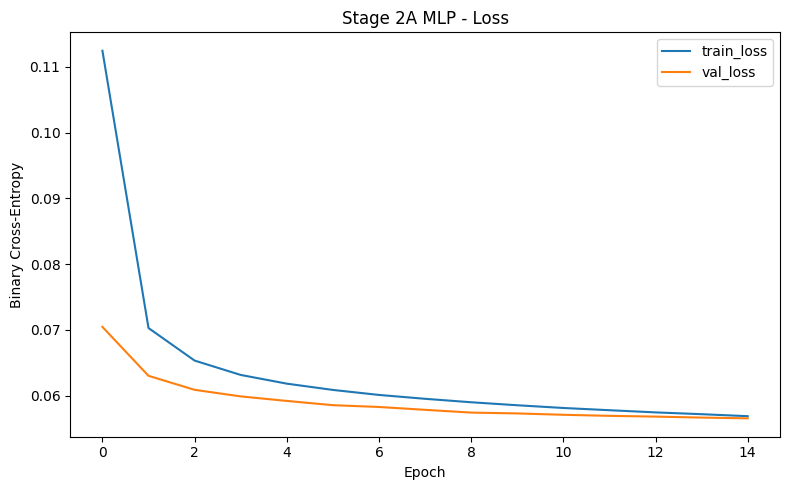

STAGE 2A PASS
Test micro F1: 0.4581


In [23]:
# Cell 9 — Save curves + sample predictions + gate
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)
hist_df.to_csv(ART_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Stage 2A MLP - Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "training_curve_loss.png", dpi=170)
plt.show()

keyword_vocab = json.loads((ART_DIR / "keyword_vocab.json").read_text(encoding="utf-8"))
id2vocab = {i: w for i, w in enumerate(keyword_vocab)}
best_th = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))["best_threshold_from_val"]

y_pred_test = (test_prob >= best_th).astype(np.int32)

def decode_keywords(vec_bin, max_k=12):
    idxs = np.where(vec_bin > 0)[0][:max_k]
    return ", ".join([id2vocab[i] for i in idxs])

def decode_top_probs(prob_vec, max_k=12):
    idxs = np.argsort(prob_vec)[::-1][:max_k]
    return ", ".join([id2vocab[i] for i in idxs])

sample_n = min(25, len(test_names))
rows = []
for i in range(sample_n):
    rows.append({
        "image_name": str(test_names[i]),
        "true_keywords": decode_keywords(y_test[i], max_k=12),
        "pred_keywords_thresholded": decode_keywords(y_pred_test[i], max_k=12),
        "pred_top12_by_prob": decode_top_probs(test_prob[i], max_k=12),
    })

pd.DataFrame(rows).to_csv(ART_DIR / "test_keyword_predictions_sample.csv", index=False)
model.save(MODEL_DIR / "mlp_keyword_baseline.keras")

required = [
    ART_DIR / "keyword_vocab.json",
    ART_DIR / "mobilenetv2_features_224.npz",
    ART_DIR / "training_history.csv",
    ART_DIR / "training_curve_loss.png",
    ART_DIR / "threshold_search_val.csv",
    ART_DIR / "metrics.json",
    ART_DIR / "test_keyword_predictions_sample.csv",
    ART_DIR / "selected_split_sizes.json",
    MODEL_DIR / "mlp_keyword_baseline.keras",
]
for p in required:
    assert p.exists(), f"Missing: {p}"

m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))
assert not np.isnan(m["test_micro_f1"]), "test_micro_f1 is NaN"

print("STAGE 2A PASS")
print("Test micro F1:", round(m["test_micro_f1"], 4))
